1\. **Maximum wind speed prediction at the Sprogø station**

The exercise goal is to predict the maximum wind speed occurring every 50 years even if no measure exists for such a period. The available data are only measured over 21 years at the Sprogø meteorological station located in Denmark. 

The annual maxima are supposed to fit a normal probability density function. However such function is not going to be estimated because it gives a probability from a wind speed maxima. Finding the maximum wind speed occurring every 50 years requires the opposite approach, the result needs to be found from a defined probability. That is the quantile function role and the exercise goal will be to find it. In the current model, it is supposed that the maximum wind speed occurring every 50 years is defined as the upper 2% quantile.

By definition, the quantile function is the inverse of the cumulative distribution function. The latter describes the probability distribution of an annual maxima. In the exercise, the cumulative probability $p_i$ for a given year i is defined as $p_i = i/(N+1)$ with $N = 21$, the number of measured years. Thus it will be possible to calculate the cumulative probability of every measured wind speed maxima. From those experimental points, the scipy.interpolate module will be very useful for fitting the quantile function. Finally the 50 years maxima is going to be evaluated from the cumulative probability of the 2% quantile.

Practically, load the dataset:

```python
import numpy as np
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]
```

Compute then the cumulative probability $p_i$ (`cprob`) and sort the maximum speeds from the data. Use then the  UnivariateSpline from scipy.interpolate to define a quantile function and thus estimate the probabilities.

In the current model, the maximum wind speed occurring every 50 years is defined as the upper 2% quantile. As a result, the cumulative probability value will be:

```python
fifty_prob = 1. - 0.02
```

So the storm wind speed occurring every 50 years can be guessed as:

``` python
fifty_wind = quantile_func(fifty_prob)
```

In [1]:
import numpy as np
import scipy.interpolate
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

max_speeds = np.load('max-speeds.npy')
years_nb = len(max_speeds)

print(f"Number of years recorded: {years_nb}")
print(f"Max wind speeds: {max_speeds}")

Number of years recorded: 21
Max wind speeds: [28.09 22.46 26.65 26.65 28.79 30.19 26.19 26.75 23.34 24.16 29.75 27.93
 26.68 23.85 32.97 25.79 26.37 25.28 26.73 23.2  26.76]


In [2]:
# Sort the wind speed data
sorted_speeds = np.sort(max_speeds)

# Compute cumulative probabilities
cprob = np.array([(i+1) / (years_nb + 1) for i in range(years_nb)])

# Print cumulative probabilities
print(f"Cumulative probabilities:\n{cprob}")
print(f"Sorted max speeds:\n{sorted_speeds}")
#plt.plot(np.arange(years_nb), max_speeds)

Cumulative probabilities:
[0.04545455 0.09090909 0.13636364 0.18181818 0.22727273 0.27272727
 0.31818182 0.36363636 0.40909091 0.45454545 0.5        0.54545455
 0.59090909 0.63636364 0.68181818 0.72727273 0.77272727 0.81818182
 0.86363636 0.90909091 0.95454545]
Sorted max speeds:
[22.46 23.2  23.34 23.85 24.16 25.28 25.79 26.19 26.37 26.65 26.65 26.68
 26.73 26.75 26.76 27.93 28.09 28.79 29.75 30.19 32.97]


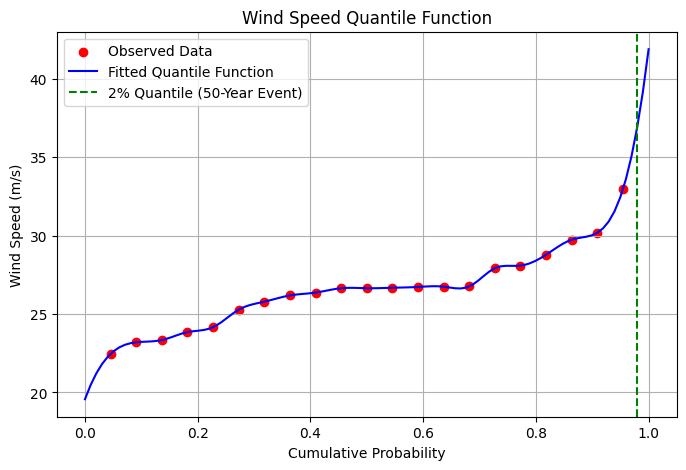

Predicted maximum wind speed for a 50-year event: 36.97 m/s


In [3]:
# Fit a spline to estimate the quantile function
quantile_func = UnivariateSpline(cprob, sorted_speeds, s=0)
# Compute the 50-year wind speed
fifty_prob = 1.0 - 0.02  # Upper 2% quantile
fifty_wind = quantile_func(fifty_prob)

# Plot the fitted quantile function
plt.figure(figsize=(8, 5))
plt.scatter(cprob, sorted_speeds, label="Observed Data", color='red')
x_vals = np.linspace(0, 1, 100)
plt.plot(x_vals, quantile_func(x_vals), label="Fitted Quantile Function", color='blue')
plt.axvline(0.98, linestyle="--", color="green", label="2% Quantile (50-Year Event)")
plt.xlabel("Cumulative Probability")
plt.ylabel("Wind Speed (m/s)")
plt.legend()
plt.title("Wind Speed Quantile Function")
plt.grid()
plt.show()

# Print the predicted wind speed
print(f"Predicted maximum wind speed for a 50-year event: {fifty_wind:.2f} m/s")


2\. **Curve fitting of temperature in Alaska** 

The temperature extremes in Alaska for each month, starting in January, are given by (in degrees Celcius):

max:  17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18

min: -62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58

* Plot these temperature extremes.
* Define a function that can describe min and max temperatures. 
* Fit this function to the data with scipy.optimize.curve_fit().
* Plot the result. Is the fit reasonable? If not, why?
* Is the time offset for min and max temperatures the same within the fit accuracy?

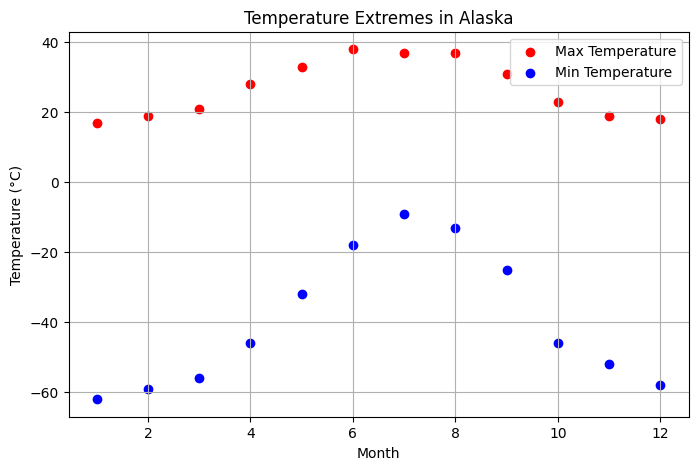

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define months (1 to 12)
months = np.arange(1, 13)

# Define temperature extremes for each month
max_temps = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
min_temps = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])

# Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(months, max_temps, color='red', label="Max Temperature")
plt.scatter(months, min_temps, color='blue', label="Min Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Extremes in Alaska")
plt.legend()
plt.grid()
plt.show()

In [5]:
#  from the scatter-plot the function should be periodic and sinusoidal (cos)

def seasonal_model(m, A, B, phi):
    return A * np.cos(2*np.pi * (m - phi) / 12) + B

params_max, _ = curve_fit(seasonal_model, xdata=months, ydata=max_temps, p0=[30, 10, 6])
params_min, _ = curve_fit(seasonal_model, xdata=months, ydata=min_temps, p0=[30, -30, 7])

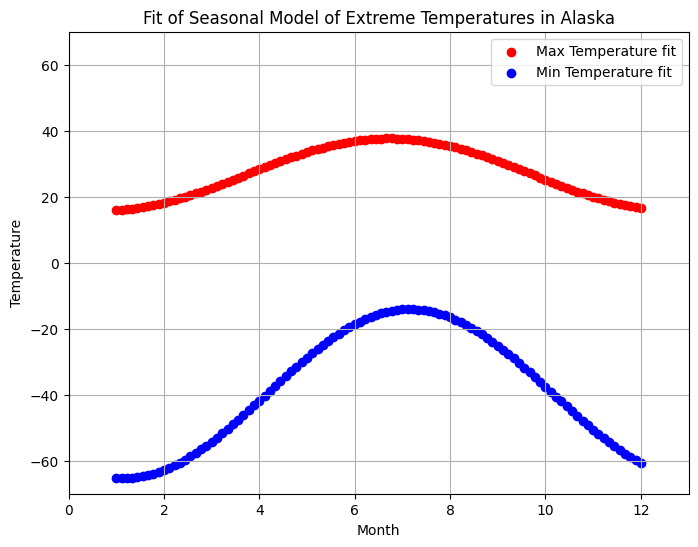

In [6]:
A_max, B_max, phi_max = params_max
A_min, B_min, phi_min = params_min

smooth_months = np.linspace(1, 12, 100)
fit_seasonal_model_max = seasonal_model(smooth_months, *params_max)
fit_seasonal_model_min = seasonal_model(smooth_months, *params_min)

plt.figure(figsize=(8, 6))
plt.scatter(
    x=smooth_months, 
    y=fit_seasonal_model_max, 
    label='Max Temperature fit', 
    color='Red'
)
plt.scatter(
    x=smooth_months, 
    y=fit_seasonal_model_min, 
    label='Min Temperature fit', 
    color='Blue'
)
plt.xlim(0, 13)
plt.ylim(-70, 70)
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.legend()
plt.grid()
plt.title('Fit of Seasonal Model of Extreme Temperatures in Alaska')
plt.show()


In [7]:
#   Assess time offset for min and max temperatures the same within the fit accuracy?
print(
    "Assess reasonability of fitted model:\n",
    "Equality within default tolerance (absolute 1 degree):",
    "\n Mean temperatures"
    "\n  Max:", np.allclose(B_max.max(), max_temps.mean(), atol=1), 
    "\n  Min:", np.allclose(B_min.mean(), min_temps.mean(), atol=1),
    "\n Peak values (tolerance 2 degrees):",
    "\n  Max:", np.allclose(2*A_max.max(), max_temps.max()-max_temps.min(), atol=2),
    "\n  Min:", np.allclose(2*A_min.max(), min_temps.max()-min_temps.min(), atol=2),
    "\n Time off-set between min and max temperatures",
    "\n  Measurements set:", abs(float(months[max_temps == max_temps.max()] - months[min_temps == min_temps.max()])),
    f"\n  Fitted Model: {abs(phi_max - phi_min):.2f}"
)

Assess reasonability of fitted model:
 Equality within default tolerance (absolute 1 degree): 
 Mean temperatures
  Max: True 
  Min: True 
 Peak values (tolerance 2 degrees): 
  Max: True 
  Min: True 
 Time off-set between min and max temperatures 
  Measurements set: 1.0 
  Fitted Model: 0.43


/var/folders/gs/gq30q7ps44jdqztv6g2t9vg00000gn/T/ipykernel_36642/2048919432.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "\n  Measurements set:", abs(float(months[max_temps == max_temps.max()] - months[min_temps == min_temps.max()])),


3\. **2D minimization of a six-hump camelback function**

$$
f(x,y) = \left(4-2.1x^2+\frac{x^4}{3} \right) x^2 +xy + (4y^2 -4)y^2
$$

has multiple global and local minima. Find the global minima of this function.

Hints:

* Variables can be restricted to $-2 < x < 2$ and $-1 < y < 1$.
* Use numpy.meshgrid() and pylab.imshow() to find visually the regions.
* Use scipy.optimize.minimize(), optionally trying out several of its methods.

How many local minima are there, and what is the function value at those points? What happens for an initial guess of $(x, y) = (0, 0)$ ?


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define the Six-Hump Camelback function
def camelback(xy):
    x, y = xy
    return (4 - 2.1 * x**2 + (x**4) / 3) * x**2 + x*y + (4*y**2 - 4) * y**2

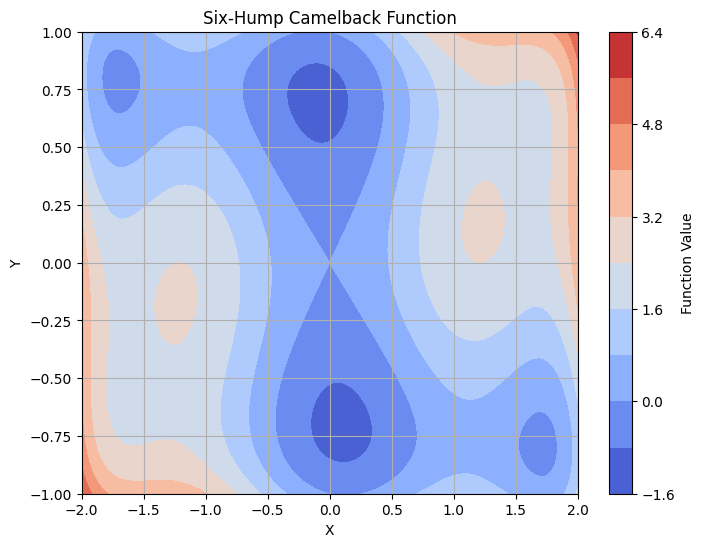

In [9]:
# Define meshgrid for visualization
x_vals = np.linspace(-2, 2, 400)
y_vals = np.linspace(-1, 1, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = camelback([X, Y])

# Plot the function
plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=10, cmap="coolwarm")
plt.colorbar(label="Function Value")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Six-Hump Camelback Function")
plt.grid()
plt.show()

In [10]:
bounds = [(-2, 2), (-1, 1)]
initial_guesses = [[-0.5, -0.5], [-0.5, 0.75]]

results = []
for guess in initial_guesses:
    res = minimize(camelback, guess, method='Powell', bounds=bounds)
    results.append(res)

minima = np.array([res.x for res in results])
minima = np.unique(np.round(minima, decimals=6), axis=0)

Global Minima Found:
x = -0.089887, y = 0.712668, f(x, y) = -1.031628
x = 0.089842, y = -0.712665, f(x, y) = -1.031628


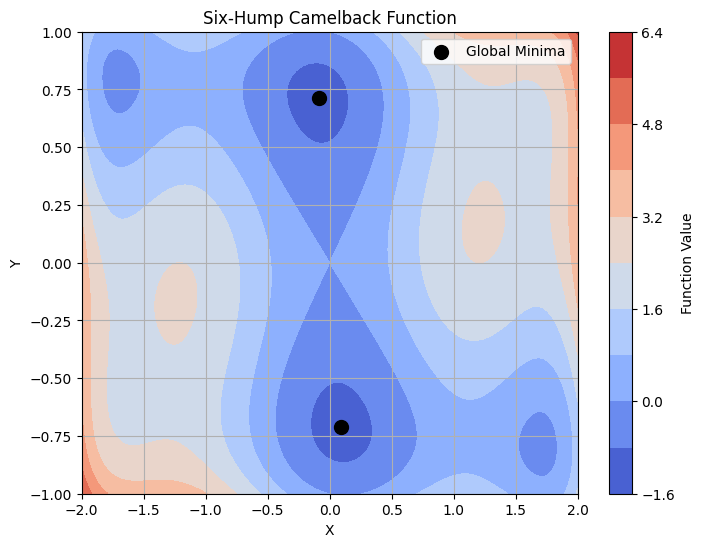

In [11]:
print("Global Minima Found:")
for min_point in minima:
    print(f"x = {min_point[0]:.6f}, y = {min_point[1]:.6f}, f(x, y) = {camelback(min_point):.6f}")

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=10, cmap="coolwarm")
plt.colorbar(label="Function Value")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Six-Hump Camelback Function")
plt.grid()
plt.scatter(minima[:, 0], minima[:, 1], color="black", marker="o", 
            s=100, label="Global Minima"
)
plt.legend()
plt.show()

In [12]:
# Test with initial guess (0,0)
res_origin = minimize(camelback, x0=[0, 0], method='Powell', bounds=bounds)
print(f"Starting at (0,0), the optimizer finds: x = {res_origin.x[0]:.6f}, y = {res_origin.x[1]:.6f}, f(x, y) = {res_origin.fun:.6f}")

Starting at (0,0), the optimizer finds: x = -0.089846, y = 0.712679, f(x, y) = -1.031628


4\. **FFT of a simple dataset**

Perform a periodicity analysis on the lynxs-hares population

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter, MaxNLocator
import scipy as sp
import pandas as pd

filename = "/Users/Filippo/Documents/UniPd/LABORATORY OF COMPUTATIONAL PHYSICS (MOD. A)/LaboratoryOfComputationalPhysics_Y7/populations.txt"
data = pd.read_csv(filepath_or_buffer=filename, delimiter='\t')
data.head()

,# year,hare,lynx,carrot
0,1900,30000.0,4000.0,48300
1,1901,47200.0,6100.0,48200
2,1902,70200.0,9800.0,41500
3,1903,77400.0,35200.0,38200
4,1904,36300.0,59400.0,40600


In [14]:
a_data = np.array(data.drop(columns='carrot'))
years = a_data[:, 0]
populations = a_data[:, 1:]
populations

array([[30000.,  4000.],
       [47200.,  6100.],
       [70200.,  9800.],
       [77400., 35200.],
       [36300., 59400.],
       [20600., 41700.],
       [18100., 19000.],
       [21400., 13000.],
       [22000.,  8300.],
       [25400.,  9100.],
       [27100.,  7400.],
       [40300.,  8000.],
       [57000., 12300.],
       [76600., 19500.],
       [52300., 45700.],
       [19500., 51100.],
       [11200., 29700.],
       [ 7600., 15800.],
       [14600.,  9700.],
       [16200., 10100.],
       [24700.,  8600.]])

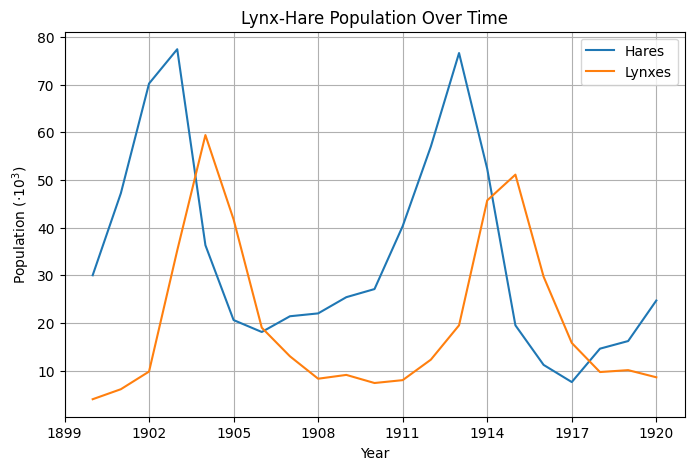

From dataset it seems the period of the population growth of hares and lynxes is about 10 years


In [15]:
plt.figure(figsize=(8, 5))
plt.plot(years, populations * 1e-3)
plt.xlabel("Year")
plt.ylabel(r"Population ($\cdot10^3$)")
plt.title("Lynx-Hare Population Over Time")
plt.legend(["Hares", "Lynxes"], loc=1)
plt.grid()
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

print("From dataset it seems the period of the population growth of hares and lynxes is about 10 years")

In [16]:
fft_populations = sp.fft.fft(populations.T).T

power_specs = np.abs(fft_populations) ** 2

frequencies = sp.fft.fftfreq(len(populations), years[1] - years[0])
pos_mask = frequencies > 0
frequencies = frequencies[pos_mask]
power_specs = power_specs[pos_mask, :]
periods = 1 / frequencies
dominant_period = 1 / frequencies[np.argmax(power_specs, axis=0)]


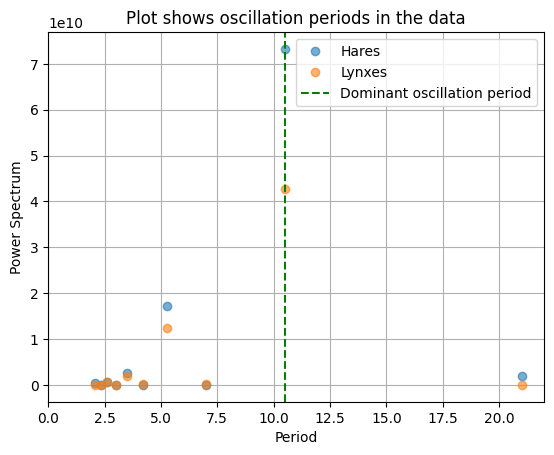

In [17]:
plt.figure()
plt.plot(periods, power_specs, "o", alpha=0.6)
plt.xlim(0, 22)
plt.xlabel("Period")
plt.ylabel("Power Spectrum")
plt.axvline(dominant_period[0], linestyle="--", color="green")
plt.legend(["Hares", "Lynxes", "Dominant oscillation period"])
plt.grid()
plt.title("Plot shows oscillation periods in the data")
plt.show()

In [18]:
print(f"Population evolution cycle period for the Hare and Lynx populaions: {dominant_period[0]} years")

Population evolution cycle period for the Hare and Lynx populaions: 10.5 years


5\. **FFT of an image**

* Examine the provided image `moonlanding.png`, which is heavily contaminated with periodic noise. In this exercise, we aim to clean up the noise using the Fast Fourier Transform.
* Load the image using pylab.imread().
* Find and use the 2-D FFT function in scipy.fftpack, and plot the spectrum (Fourier transform of) the image. Do you have any trouble visualising the spectrum? If so, why?
* The spectrum consists of high and low frequency components. The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).
* Apply the inverse Fourier transform to see the resulting image.

Denoise an image by implementing a blur with an FFT.

+ Implement, via FFT, the following convolution:

    + $f_1(t) = \int dt'\, K(t-t') f_0(t')$

    + $\tilde{f}_1(\omega) = \tilde{K}(\omega) \tilde{f}_0(\omega)$

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from matplotlib.colors import LogNorm

Text(0.5, 1.0, 'Moon Landing Original Image')

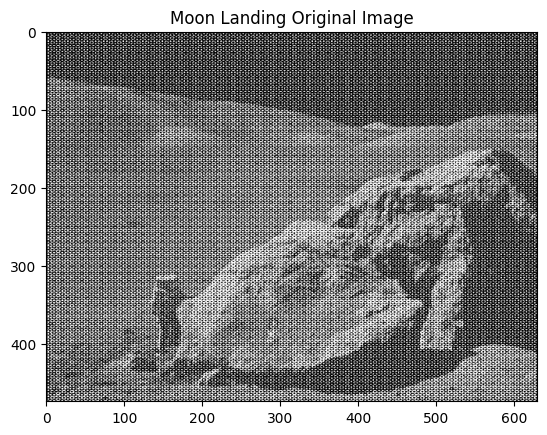

In [36]:
image = plt.imread(
    "/Users/Filippo/Documents/UniPd/LABORATORY OF COMPUTATIONAL PHYSICS (MOD. A)/LaboratoryOfComputationalPhysics_Y7/moonlanding.png"
).astype(float)
plt.figure()
plt.imshow(image, "gray")
plt.title("Moon Landing Original Image")

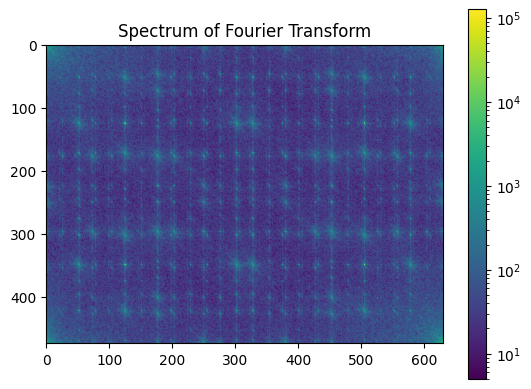

In [37]:
image_fft = sp.fft.fft2(image)
spectrum = np.abs(image_fft)

plt.figure()
plt.imshow(spectrum, norm=LogNorm(vmin=5))
plt.colorbar()
plt.title("Spectrum of Fourier Transform")
plt.show()

Text(0.5, 1.0, 'Filtered Spectrum')

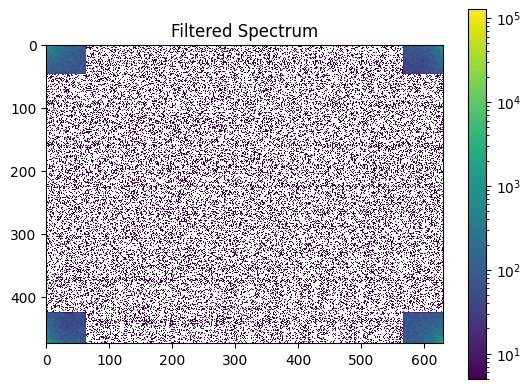

In [38]:
#   high-frequency values are contained at the edges of the spectrum
image_fft2 = image_fft.copy()
r, c = image_fft2.shape
keep = 0.1      #   keep 10% of the total values (the 4 corners in the spectrum image)
image_fft2[int((r * keep)) : int(r * (1 - keep) )] = 0

image_fft2[:, int((c * keep)) : int(c * (1 - keep) )] = 0
spectrum2 = np.abs(image_fft2)
plt.figure()
plt.imshow(spectrum2, norm=LogNorm(vmin=5))
plt.colorbar()
plt.title("Filtered Spectrum")

Text(0.5, 1.0, 'Reconstructed Image')

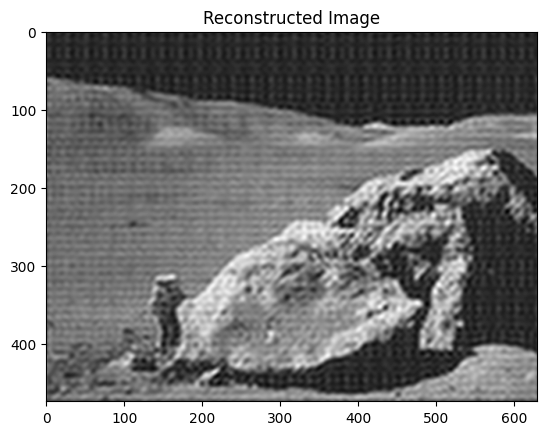

In [41]:
# Reconstruct the denoised image
image_new = sp.fft.ifft2(image_fft2).real
plt.figure()
plt.imshow(image_new, "gray")
plt.title("Reconstructed Image")